In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import pickle as pkl
import numpy as np
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *
from vae import *

In [3]:
#on runai
with open('/mydata/cope/mirco/data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/mydata/cope/mirco/data/ssp585_time_series.pkl'

In [18]:
#on local
with open('cope_data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

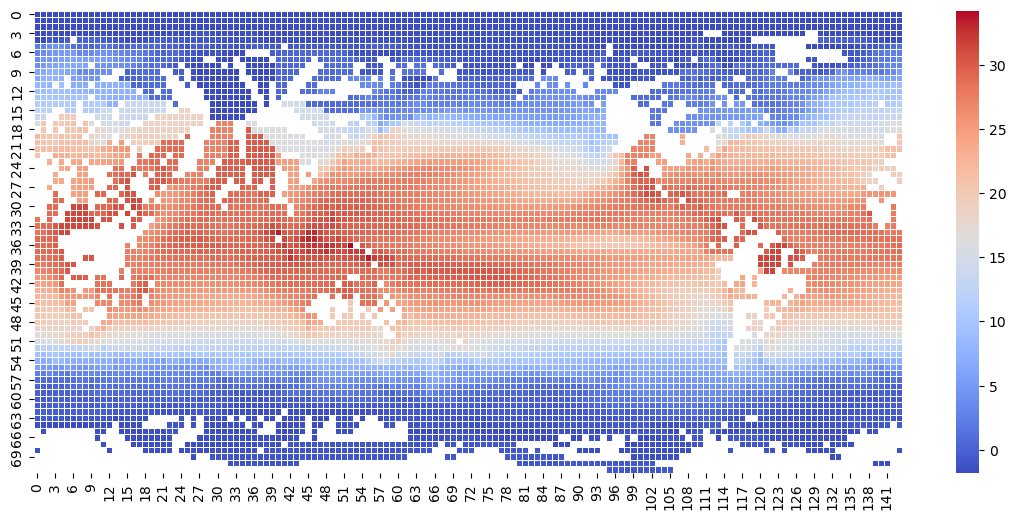

In [19]:
plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

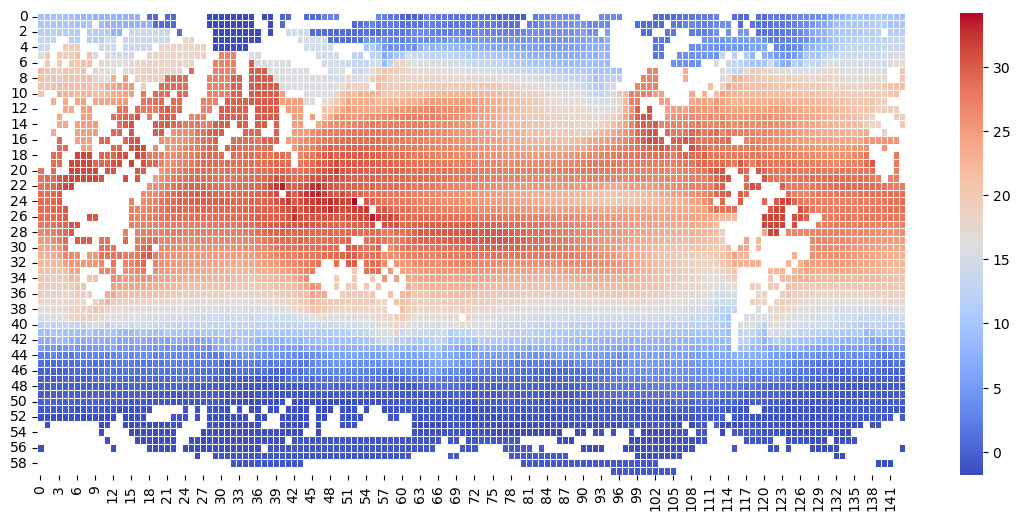

In [ ]:
prune(cope_data, min_runs=5)
cut_lat(cope_data, max_lat=60)
#downscale(cope_data)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

In [22]:
union_nan_mask = find_union_nan_mask(cope_data)
union_nan_mask

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ..., False,  True, False],
       [False, False,  True, ..., False, False, False]], shape=(60, 144))

In [23]:
union_nan_mask.shape

(60, 144)

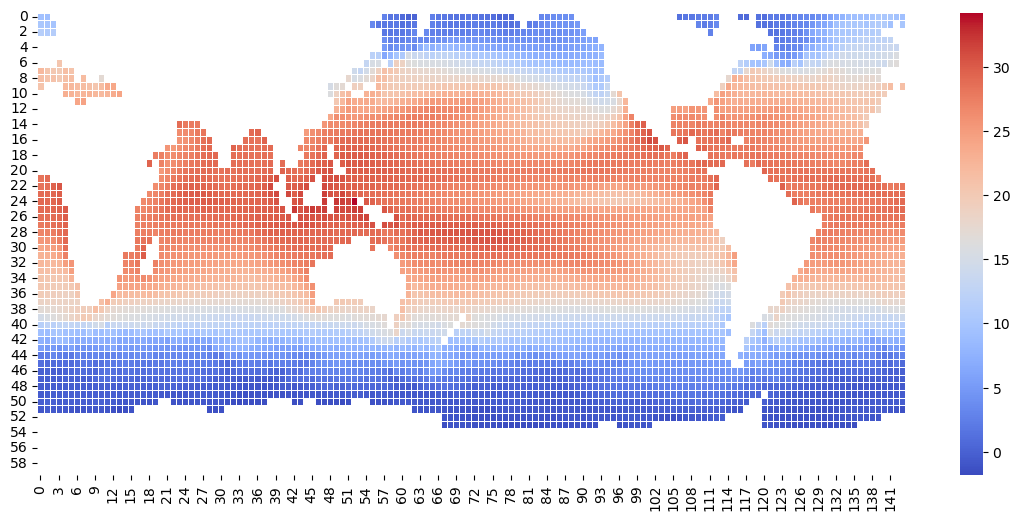

In [24]:
inpute(cope_data, union_nan_mask)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

In [25]:
a = cope_data['ICON-ESM-LR']['r1i1p1f1'][131, :, :]

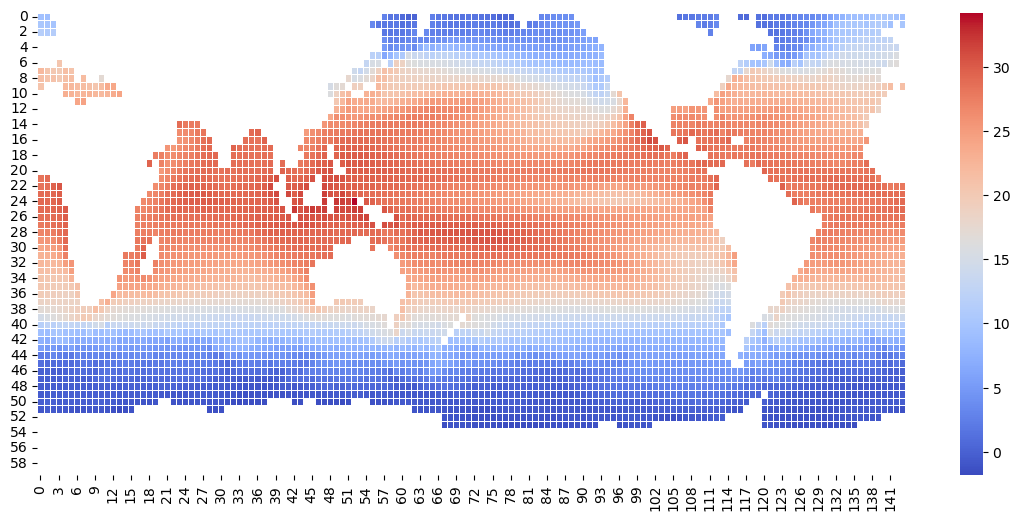

In [26]:
plot_grid(a)

In [27]:
norm_flat_grids, mean_flat_forced_responses, mean_flat_grid, std_flat_grid_timeserie = normalize_flatten_model(cope_data, 'ICON-ESM-LR', union_nan_mask)

In [28]:
norm_flat_grids

{'r1i1p1f1': array([[-0.65153975, -0.67438948, -0.7735636 , ...,  0.12563572,
          0.07334877,  0.40222659],
        [-1.45818708, -0.79121702, -0.79348297, ..., -0.64396933,
         -0.7975896 , -0.49407117],
        [-1.60867784, -0.76913441, -2.14791935, ..., -0.47302785,
         -1.47394049, -1.65150439],
        ...,
        [ 0.74252974,  2.57439598,  0.25699841, ...,  0.41499046,
          0.07293723,  0.23228505],
        [ 1.62908863, -1.23837604, -1.53686667, ..., -1.0268191 ,
         -1.15134279, -1.05154762],
        [-1.09475639,  2.22481309,  1.72563763, ..., -0.9932872 ,
         -1.27441293, -1.33406578]], shape=(34, 5666)),
 'r2i1p1f1': array([[-0.02969711, -0.80179999, -2.1534753 , ..., -2.36280547,
         -2.37918361, -1.77011946],
        [-1.22886553,  0.80508043, -0.78566274, ..., -1.45808218,
         -1.24430333, -1.19067617],
        [-1.24849101,  0.53203462, -0.41697844, ..., -0.72165775,
         -1.5866574 , -1.22464592],
        ...,
        [-0.

In [29]:
min([norm_flat_grids['r5i1p1f1'][i].min() for i in range(norm_flat_grids['r1i1p1f1'].shape[0])])


np.float64(-29.65478427887121)

In [30]:
norm_flat_grids['r1i1p1f1'].shape

(34, 5666)

In [44]:
union_nan_mask.shape

(60, 144)

In [49]:
from_flat_to_grid(norm_flat_grids['r1i1p1f1'][0], union_nan_mask)

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [ 0.06844307,  0.30890251,  0.0556482 , ...,         nan,
                nan,         nan],
       [ 0.43656447,  0.85524318,  0.48704187, ..., -0.87636424,
                nan,  0.22825283],
       [ 0.67847346,  0.39877515,         nan, ...,  0.12563572,
         0.07334877,  0.40222659]], shape=(60, 144))

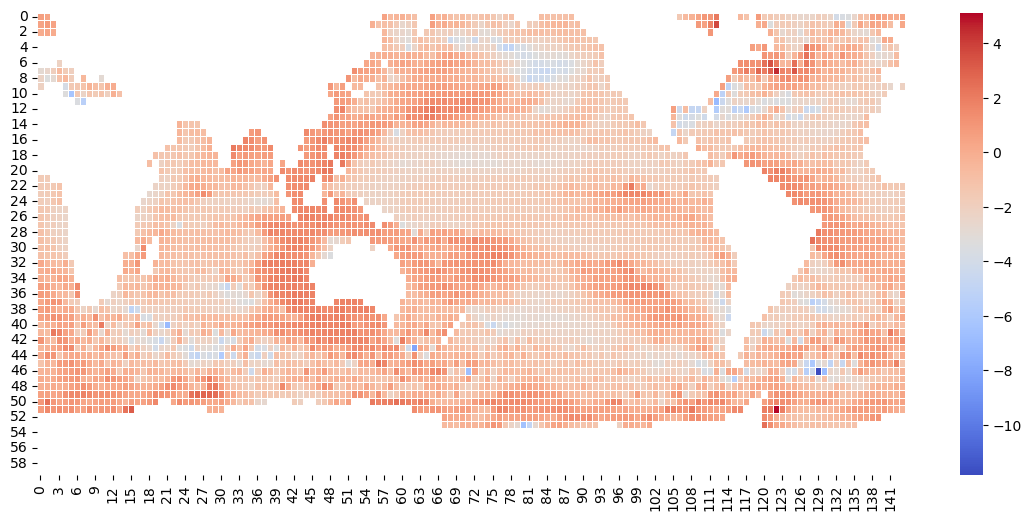

In [51]:
plot_grid(from_flat_to_grid(norm_flat_grids['r1i1p1f1'][0], union_nan_mask))

In [52]:
union_nan_mask.shape

(60, 144)

In [53]:
X, Y = extract_matrices(cope_data, union_nan_mask)

In [54]:
X.shape

(23224, 5666)

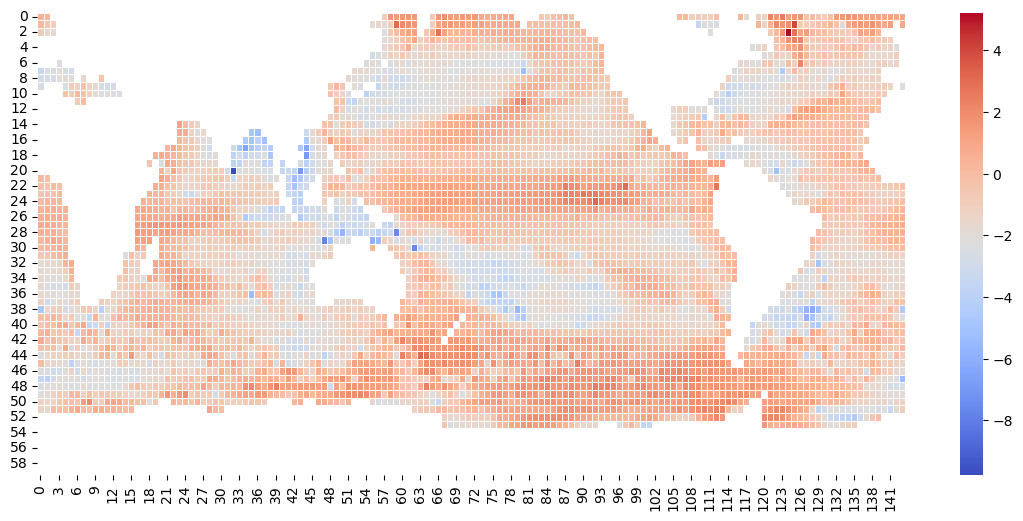

In [59]:
plot_grid(from_flat_to_grid(X[4], union_nan_mask))

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [64]:
batch_size = 128

cope_dataset = CopeDataset(samples=X, labels=Y)

train_dataset, test_dataset = random_split(cope_dataset, [0.8, 0.2])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [65]:
lr = 1e-3

model = basic_VAE(input_dim=5666, hidden_dim=1000, latent_dim=200).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

epochs = 30

print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = vae_loss(x_hat, y, mean, var)
        
        overall_loss += loss.mean().item()
        
        loss.backward()
        optimizer.step()
        
    print("\tEpoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
	Epoch 1 complete ! 	Average Loss:  23729.636323915678


KeyboardInterrupt: 

In [9]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        
        x_hat, _, _ = model(x)

        break

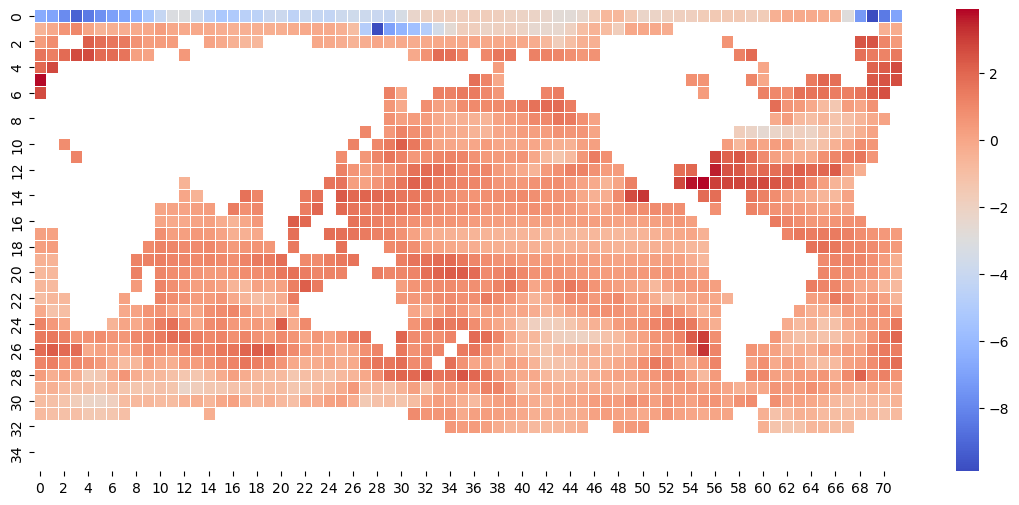

In [16]:
grid = from_flat_to_grid(x[2], union_nan_mask, downscale=True)
plot_grid(grid, flip=True)

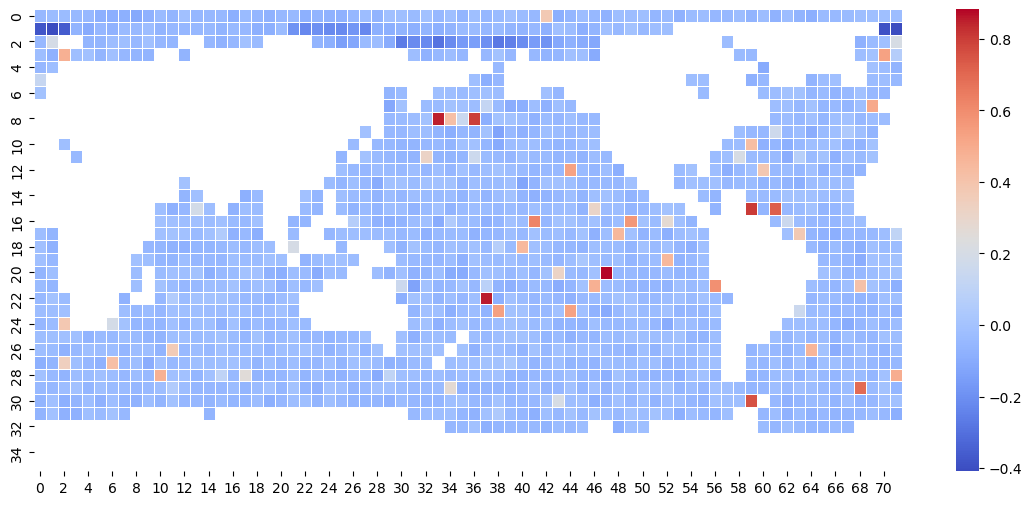

In [18]:
grid = from_flat_to_grid(x_hat[2].detach().numpy(), union_nan_mask, downscale=True)
plot_grid(grid, flip=True)